# Job Title and Description Preprocessing & Visualization

This notebook focuses on loading the job dataset, performing preprocessing, and visualizing key insights.

In [250]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

[nltk_data] Downloading package stopwords to /home/kamal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/kamal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/kamal/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 1. Load Data

In [251]:
# Load the dataset
df = pd.read_csv('job_title_des.csv', index_col=0)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2277, 2)


,Job Title,Job Description
0,Flutter Developer,We are looking for hire experts flutter develo...
1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...
2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n..."
3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside o...
4,Full Stack Developer,job responsibility full stack engineer – react...


## 2. Exploratory Data Analysis (EDA)

In [252]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Basic info
df.info()

Missing values:
 Job Title          0
Job Description    0
dtype: int64
<class 'pandas.DataFrame'>
Index: 2277 entries, 0 to 2403
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Job Title        2277 non-null   str  
 1   Job Description  2277 non-null   str  
dtypes: str(2)
memory usage: 53.4 KB


## 3. Preprocessing

In [253]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)

# Initialize lemmatizer and stopwords outside the function for efficiency
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove special characters and numbers, keeping C++, C#, node.js related chars
    text = re.sub(r'[^a-zA-Z\s+#.]', '', text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

# Apply preprocessing to Job Description
print("Preprocessing job descriptions...")
df['cleaned_description'] = df['Job Description'].apply(preprocess_text)
print("Preprocessing complete.")

Preprocessing job descriptions...
Preprocessing complete.


## 4. Visualizations

### 4.1 Top 10 Job Titles
Let's see which job titles are most frequent in the dataset.

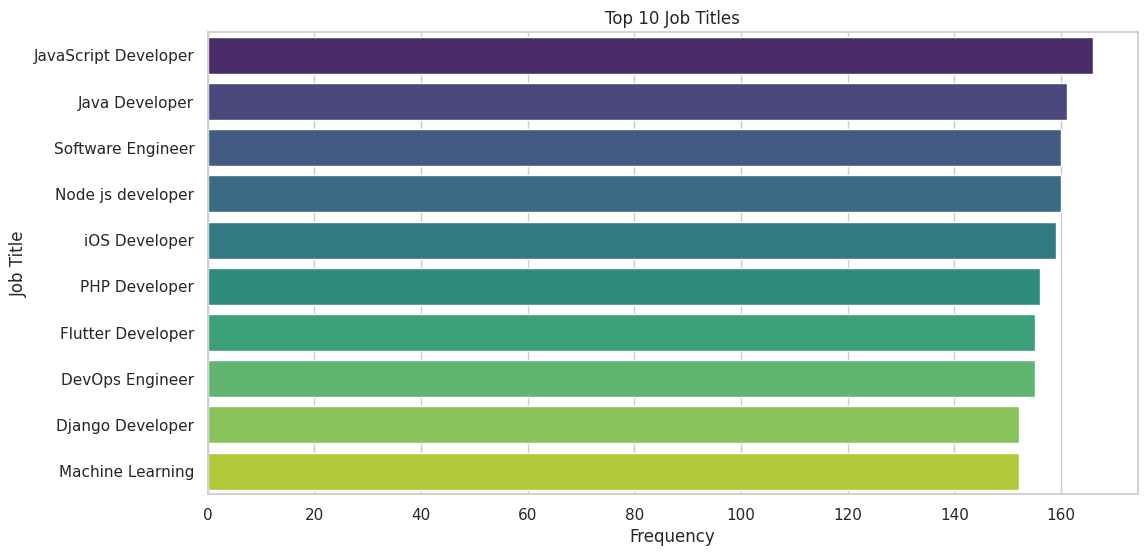

In [254]:
top_titles = df['Job Title'].value_counts().head(10)
sns.barplot(x=top_titles.values, y=top_titles.index, hue=top_titles.index, palette='viridis', legend=False)
plt.title('Top 10 Job Titles')
plt.xlabel('Frequency')
plt.ylabel('Job Title')
plt.show()

### 4.2 Job Description Length Distribution
Analyzing the length of job descriptions (word count).

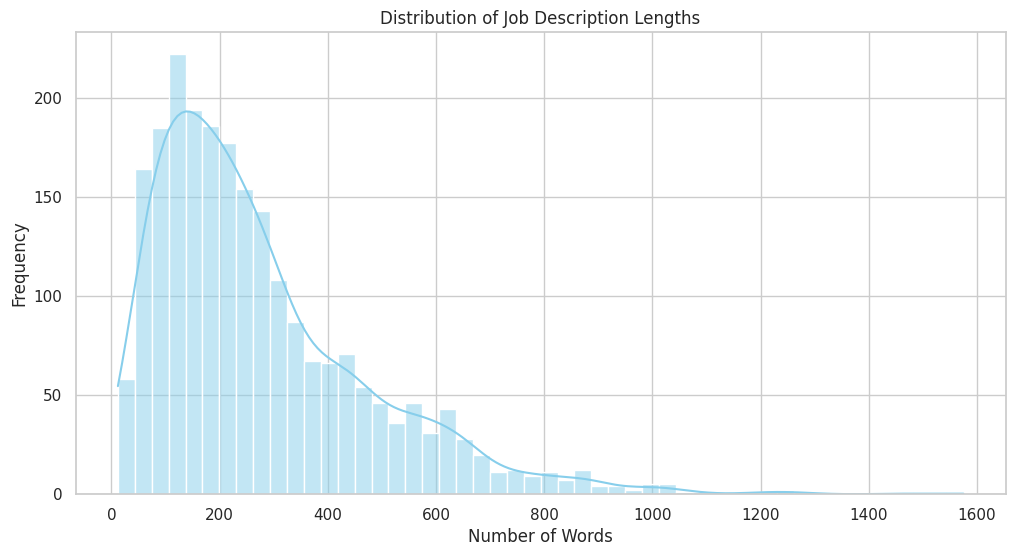

In [255]:
df['desc_len'] = df['Job Description'].str.split().str.len()
sns.histplot(df['desc_len'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Job Description Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

### 4.3 Most Common Words in Job Descriptions
Visualizing the top 20 words that appear in the cleaned descriptions.

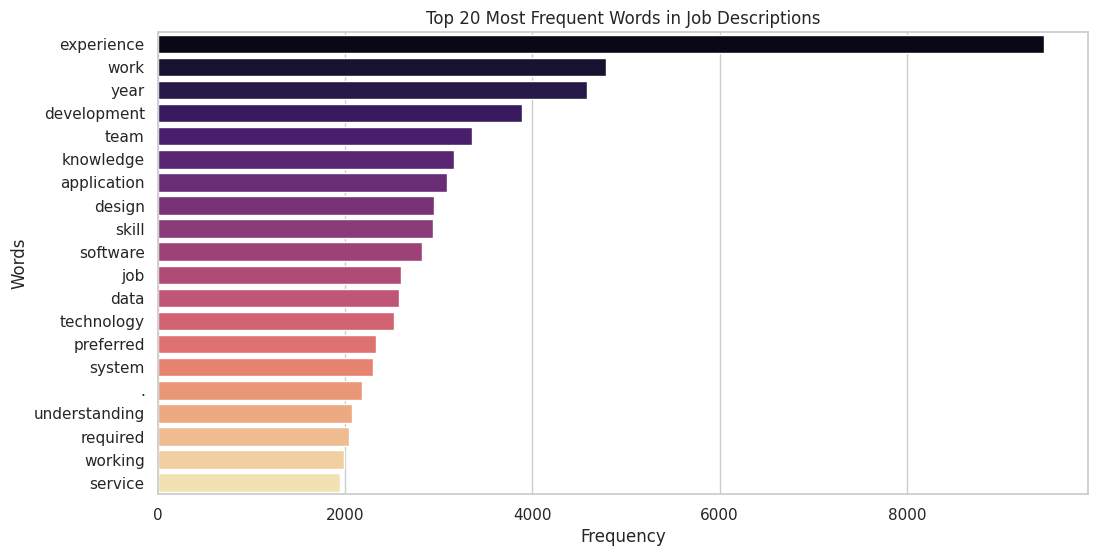

In [256]:
all_words = " ".join(df['cleaned_description']).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='magma', legend=False)
plt.title('Top 20 Most Frequent Words in Job Descriptions')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

## 5. Filter for Top 10 Jobs
Filtering the dataset to keep only the top 10 most frequent job titles.

In [257]:
# Get the top 10 job titles
top_10_titles = df['Job Title'].value_counts().head(10).index

# Filter the dataset
df = df[df['Job Title'].isin(top_10_titles)]

print(f"New dataset shape: {df.shape}")
print("Top 10 job titles included:")
print(top_10_titles.tolist())
df.head()

New dataset shape: (1576, 4)
Top 10 job titles included:
['JavaScript Developer', 'Java Developer', 'Software Engineer', 'Node js developer', 'iOS Developer', 'PHP Developer', 'Flutter Developer', 'DevOps Engineer', 'Django Developer', 'Machine Learning']


,Job Title,Job Description,cleaned_description,desc_len
0,Flutter Developer,We are looking for hire experts flutter develo...,looking hire expert flutter developer. eligibl...,61
1,Django Developer,PYTHON/DJANGO (Developer/Lead) - Job Code(PDJ ...,pythondjango developerlead job codepdj strong ...,69
2,Machine Learning,"Data Scientist (Contractor)\n\nBangalore, IN\n...",data scientist contractor bangalore responsibi...,234
3,iOS Developer,JOB DESCRIPTION:\n\nStrong framework outside o...,job description strong framework outside io al...,189
5,Java Developer,Software Developer - Integration*\nImmediate O...,software developer integration immediate openi...,392


## 6. Model Training and Evaluation
In this section, we will perform feature extraction using TF-IDF and train two models: Logistic Regression and Random Forest.

In [258]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data
X = df['cleaned_description']
y = df['Job Title']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 1260
Testing set size: 316


In [259]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the training data, transform the test data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF feature matrix shape: {X_train_tfidf.shape}")

TF-IDF feature matrix shape: (1260, 5000)


In [260]:
print("Training Logistic Regression model...")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Predictions and evaluation
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))

Training Logistic Regression model...
Logistic Regression Accuracy: 0.8956

Classification Report (Logistic Regression):
                      precision    recall  f1-score   support

     DevOps Engineer       0.97      0.97      0.97        31
    Django Developer       0.97      0.94      0.95        31
   Flutter Developer       0.86      0.97      0.91        31
      Java Developer       0.77      0.84      0.81        32
JavaScript Developer       0.85      0.88      0.87        33
    Machine Learning       0.94      0.97      0.95        31
   Node js developer       0.93      0.88      0.90        32
       PHP Developer       0.94      0.97      0.95        31
   Software Engineer       0.77      0.72      0.74        32
       iOS Developer       1.00      0.84      0.92        32

            accuracy                           0.90       316
           macro avg       0.90      0.90      0.90       316
        weighted avg       0.90      0.90      0.90       316



In [261]:
print("Training Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_tfidf, y_train)

# Predictions and evaluation
y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Training Random Forest model...
Random Forest Accuracy: 0.8861

Classification Report (Random Forest):
                      precision    recall  f1-score   support

     DevOps Engineer       0.94      0.94      0.94        31
    Django Developer       0.97      0.97      0.97        31
   Flutter Developer       0.84      1.00      0.91        31
      Java Developer       0.83      0.78      0.81        32
JavaScript Developer       0.93      0.82      0.87        33
    Machine Learning       0.88      0.97      0.92        31
   Node js developer       0.91      0.91      0.91        32
       PHP Developer       0.97      1.00      0.98        31
   Software Engineer       0.62      0.62      0.62        32
       iOS Developer       1.00      0.88      0.93        32

            accuracy                           0.89       316
           macro avg       0.89      0.89      0.89       316
        weighted avg       0.89      0.89      0.89       316



## 7. Retrieval-Augmented Generation (RAG)
In this section, we implement a RAG pipeline using FAISS for retrieval and a local Hugging Face model for generation.

In [262]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
from transformers import pipeline
import pandas as pd

In [263]:
import pickle
import os

def chunk_text(text, chunk_size=500, overlap=50):
    if pd.isna(text):
        return []
    chunks = []
    for i in range(0, len(text), chunk_size - overlap):
        chunks.append(text[i:i + chunk_size])
    return chunks

cache_file = 'rag_chunks.pkl'

if os.path.exists(cache_file):
    print("Loading chunks from cache...")
    with open(cache_file, 'rb') as f:
        cache_data = pickle.load(f)
        all_chunks = cache_data['all_chunks']
        chunk_metadata = cache_data['chunk_metadata']
else:
    print("Chunking job descriptions...")
    all_chunks = []
    chunk_metadata = []

    if 'df' not in globals():
        df = pd.read_csv('job_title_des.csv', index_col=0)

    for idx, row in df.iterrows():
        # Use original job description for better context
        chunks = chunk_text(row['Job Description'])
        for chunk in chunks:
            all_chunks.append(chunk)
            chunk_metadata.append({'Job Title': row['Job Title'], 'Original_Idx': idx})
            
    print("Saving chunks to cache...")
    with open(cache_file, 'wb') as f:
        pickle.dump({'all_chunks': all_chunks, 'chunk_metadata': chunk_metadata}, f)

print(f"Loaded {len(all_chunks)} chunks.")

Loading chunks from cache...
Loaded 7711 chunks.


In [264]:
print("Loading embedding model...")
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating embeddings for chunks (this may take a minute)...")
chunk_embeddings = embedding_model.encode(all_chunks, show_progress_bar=True)

# Build FAISS index
d = chunk_embeddings.shape[1] # Dimension of embeddings
faiss_index = faiss.IndexFlatL2(d)
faiss_index.add(np.array(chunk_embeddings).astype('float32'))
print(f"FAISS index built with {faiss_index.ntotal} vectors.")

Loading embedding model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6550.22it/s]


Generating embeddings for chunks (this may take a minute)...


Batches: 100%|██████████| 241/241 [02:09<00:00,  1.87it/s]

FAISS index built with 7711 vectors.


In [265]:
def retrieve_context(query, k=3):
    query_embedding = embedding_model.encode([query]).astype('float32')
    distances, indices = faiss_index.search(query_embedding, k)
    
    retrieved_texts = []
    for i in indices[0]:
        retrieved_texts.append(all_chunks[i])
        
    return retrieved_texts

# Test retrieval
test_query = "What are the responsibilities of a Python developer?"
contexts = retrieve_context(test_query, k=2)
print("Retrieved Contexts for test query:\n")
for i, ctx in enumerate(contexts):
    print(f"Context {i+1}: {ctx}\n")

Retrieved Contexts for test query:

Context 1: technologies is necessary as well.

Duties and Responsibilities:

Daily duties for Python developers vary based on the websites, applications, and programs used by the hiring company. However, these main responsibilities are the same across all businesses and industries:

· Maintain Existing Programs: Python developers maintain existing programs and apps used by the company, troubleshooting to spot potential problems and ensuring they continue to function smoothly.

· Write New Programs: Python 

Context 2: frameworks, and patterns. As a Python Junior Developer, your primary responsibilities will be support – design and develop, maintain and enhance applications. Therefore, it’s essential that – as a Python Junior Developer — you are trained at problem solving, solution design, logical thinking and high-quality coding.

RESPONSIBILITIES:
Python Junior Developer:
Willing to learn and support in delivering high-quality application

Involve i

In [266]:
print("Loading text generation model...")
# Using flan-t5-small as a fast, lightweight local model suitable for instruction following
generator = pipeline("text-generation", model="HuggingFaceTB/SmolLM2-135M-Instruct", max_new_tokens=150)

def ask_rag(query):
    contexts = retrieve_context(query, k=3)
    context_str = " ".join(contexts)
    
    # Create augmented prompt
    prompt = f"Answer the question based on the following context.\n\nContext:\n{context_str}\n\nQuestion: {query}\n\nAnswer:"
    
    response = generator(prompt)
    return response[0]['generated_text']

# Example query
query = "What programming languages are required for a Machine Learning position?"
print(f"Query: {query}\n")
print(f"RAG Answer: {ask_rag(query)}")

Loading text generation model...


Loading weights: 100%|██████████| 272/272 [00:00<00:00, 10238.73it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Query: What programming languages are required for a Machine Learning position?



[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


RAG Answer: Answer the question based on the following context.

Context:
eferred)
Programming Languages needed:
Python (Preferred) Machine learning and Deep Tech Programming (C and C++)
Natural Language Processing, Speech Recognition, Computer Vision and Reinforcement Learning.
IDEs like Eclipse and IntelliJ to the components
Python, Java, and Scala
expert mathematical skills, knowledge of cloud applications and computer languages
Big Data platforms and tools, including Hadoop, Pig, Hive, Spark, and MapReduce
structured query language (SQL), Python, Scala, and Perl
Experience:
2+ Years
Job Types: Full-time, Walk-In
Salary:   Statistics or Mathematics, artificial intelligence, machine learning, speech recognition, natural language processing, operations research, or related technical field.
1+ year for PhD, 4+ years for Masters or 6+ years of Experience designing and implementing machine learning models in production environments.
Expert in at least one high level language such as Scal

## 8. AI Interview Assessment
This interactive section simulates an interview. It extracts required skills from a job description, quizzes you with MCQs and essay questions, and grades your answers.

In [267]:
import pandas as pd
import random
import re
import math

try:
    skills_df = pd.read_csv('skills.csv')
    mcqs_df = pd.read_csv('mcq_questions.csv')
    essays_df = pd.read_csv('essay_questions.csv')
    files_loaded = True
except FileNotFoundError:
    print("Error: Could not find one or more CSV files (skills.csv, mcq_questions.csv, essay_questions.csv).")
    files_loaded = False

In [268]:
def extract_skills(jd_text):
    """Extracts all matching skills from the JD based on the skills.csv file."""
    if not files_loaded: return []
    found_skills = []
    jd_lower = str(jd_text).lower()
    for skill in skills_df['skill'].tolist():
        pattern = r'\b' + re.escape(str(skill).lower()) + r'(\s|$|\.)'
        if re.search(pattern, jd_lower):
            found_skills.append(skill)
    return found_skills

def grade_essay(question, answer):
    """Uses the local LLM to grade the essay, provide feedback, and give a model answer."""
    if not answer.strip():
        return "Rating: 0/10\nFeedback: No answer provided.\nModel Answer: Please provide an answer to receive feedback."
        
    prompt = f"""<|im_start|>system\nYou are an expert technical interviewer evaluating a candidate's answer.<|im_end|>\n<|im_start|>user\nQuestion: {question}\nCandidate Answer: {answer}\n\nEvaluate the answer. Provide a rating between 0 and 10, explain why, and provide the ideal model answer.\nFormat your response EXACTLY as:\nRating: [0-10]/10\nFeedback: [Your feedback]\nModel Answer: [The ideal answer]<|im_end|>\n<|im_start|>assistant\n"""
    try:
        # Generate using max_new_tokens for causal models
        response = generator(prompt, max_new_tokens=300)
        raw_text = response[0]['generated_text']
        
        # Clean up output: Causal LMs return the prompt prepended to the output, so we split it off.
        if "<|im_start|>assistant" in raw_text:
            cleaned_text = raw_text.split("<|im_start|>assistant")[-1].strip()
        else:
            cleaned_text = raw_text.replace(prompt, '').strip()
            
        return cleaned_text
    except NameError:
        return "Error: Generator model not loaded. Please run the RAG section cells first."

In [269]:
def run_interview(jd_text):
    if not files_loaded:
        print("Cannot run interview without the required CSV files.")
        return
        
    print("--- Analyzing Job Description ---")
    skills = extract_skills(jd_text)
    
    if not skills:
        print("No matching skills found in the job description.")
        return
        
    print(f"Skills Identified: {', '.join(skills)}\n")
    
    # Get user inputs for interview configuration
    while True:
        try:
            total_q_input = input("How many total questions would you like? ")
            total_q = int(total_q_input)
            if total_q <= 0:
                print("Please enter a positive number.")
                continue
            break
        except ValueError:
            print("Please enter a valid integer.")

    mode = ""
    while mode not in ['random', 'static']:
        mode = input("Choose selection mode ('random' or 'static'): ").strip().lower()

    # Calculate distribution
    if mode == 'static':
        mcq_count = math.ceil(total_q / 2)
        essay_count = math.floor(total_q / 2)
    else: # random
        mcq_count = random.randint(0, total_q)
        essay_count = total_q - mcq_count

    # Pool available questions for the identified skills
    available_mcqs = mcqs_df[mcqs_df['Skill'].isin(skills)]
    available_essays = essays_df[essays_df['Skill'].isin(skills)]

    # Cap counts if the pool is smaller than requested
    actual_mcq_count = min(mcq_count, len(available_mcqs))
    actual_essay_count = min(essay_count, len(available_essays))
    
    if actual_mcq_count + actual_essay_count == 0:
        print("No questions available for the identified skills.")
        return

    # Sample questions
    sampled_mcqs = available_mcqs.sample(actual_mcq_count) if actual_mcq_count > 0 else pd.DataFrame()
    sampled_essays = available_essays.sample(actual_essay_count) if actual_essay_count > 0 else pd.DataFrame()

    print("\n====================================")
    print("       STARTING INTERVIEW           ")
    print(f"   {actual_mcq_count} MCQs | {actual_essay_count} Essays   ")
    print("====================================\n")
    
    mcq_score = 0
    pending_essays = []
    
    # Conduct MCQs
    if not sampled_mcqs.empty:
        for idx, row in sampled_mcqs.iterrows():
            print(f"\n[MCQ - {row['Skill']}] {row['Question']}")
            print(f"A. {row['Option_A']}")
            print(f"B. {row['Option_B']}")
            print(f"C. {row['Option_C']}")
            print(f"D. {row['Option_D']}")
            
            ans = input("Your Answer (A/B/C/D): ").strip().upper()
            if ans == row['Correct_Answer']:
                print("Correct! \u2714\uFE0F")
                mcq_score += 1
            else:
                print(f"Incorrect \u274C. The correct answer was {row['Correct_Answer']}.")

    # Conduct Essays
    if not sampled_essays.empty:
        for idx, row in sampled_essays.iterrows():
            print(f"\n[Essay - {row['Skill']}] {row['Question']}")
            ans = input("Your Answer: ").strip()
            pending_essays.append({'question': row['Question'], 'answer': ans, 'skill': row['Skill']})
            
    print("\n====================================")
    print("         INTERVIEW COMPLETE         ")
    print("====================================")
    if actual_mcq_count > 0:
        print(f"Final MCQ Score: {mcq_score}/{actual_mcq_count} ({(mcq_score/actual_mcq_count)*100:.1f}%)\n")
    else:
        print("No MCQs were in this session.\n")
        
    # Deferred AI Evaluation Phase
    if pending_essays:
        print("====================================")
        print("       AI EVALUATION PHASE          ")
        print("====================================")
        print("Grading your essays... this may take a moment.\n")
        for i, essay in enumerate(pending_essays):
            print(f"--- Essay {i+1} ({essay['skill']}) ---")
            print(f"Q: {essay['question']}")
            print(f"Your Answer: {essay['answer']}\n")
            feedback = grade_essay(essay['question'], essay['answer'])
            print(f"AI Feedback:\n{feedback}\n")


In [270]:
# ---------------------------------------------------------
# Example usage (You can replace this with any JD!)
# ---------------------------------------------------------
sample_jd = """
We are looking for a Backend Developer to join our team. 
You should have strong experience with Python and Django. 
Familiarity with Agile methodologies and Git is a plus.
"""

# Uncomment the line below to run the interview!
run_interview(sample_jd)

--- Analyzing Job Description ---
Skills Identified: Python, Git, Agile, Django


       STARTING INTERVIEW           
   2 MCQs | 1 Essays   


[MCQ - Git] Which of the following is a best practice for security when using Git?
A. Storing credentials in public repositories
B. Keeping dependencies updated and validating input
C. Disabling SSL/TLS
D. Running as root user
Correct! ✔️

[MCQ - Python] How does Python typically handle configurations?
A. Hardcoded in the source code
B. Through environment variables and standard config files
C. Via a central database only
D. It does not require configuration
Incorrect ❌. The correct answer was B.

[Essay - Django] What are the security implications of using Django in a production environment, and how can they be addressed?


[transformers] Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



         INTERVIEW COMPLETE         
Final MCQ Score: 1/2 (50.0%)

       AI EVALUATION PHASE          
Grading your essays... this may take a moment.

--- Essay 1 (Django) ---
Q: What are the security implications of using Django in a production environment, and how can they be addressed?
Your Answer: I don't know

AI Feedback:
The security implications of using Django in a production environment can be addressed by implementing robust security measures and regular security audits. Here are the reasons why:

1. **Data Security**: Django securely stores and manages user data, including passwords, tokens, and permissions. This helps in reducing the risk of data breaches and unauthorized use.

2. **API Security**: Django provides a robust API security framework, which includes features like authentication, authorization, and validation. This helps in ensuring that your Django application is secure and accessible to the right people.

3. **Data Encryption**: Django's encryption features,